# Task 8.1D Machine Learning Mini Project
## Sydney Housing Price Prediction and Decision Support System

### Name: Chehul Chinnappa T.N
### Student Id: 225269854

For this Mini project, I have selected the following suburbs:
1. Liverpool

2. Canterbury

3. Parramatta

## Part 1: Problem Definition and Data Collection

The Housing price prediction is a supervised regression problem, where the target variable is 'Sale_Price', while the physical charactersistics of each property are the predictor variables.

The dataset was manually collected from the publically available sold-property listings for Liverpool, Canterbury and Parramatta, and these suburbs were selected as they provide variation in location and housing characteristics.

The collected dataset has 150 properties, with 50 properties from each suburb.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

RANDOM_STATE = 225269854 

In [2]:
# Loading the dataset
df = pd.read_csv("House_Sold_Listings.csv")

print("Dataset shape:", df.shape)

df.head()

Dataset shape: (150, 10)


,Suburb,Sale_Price,Bedrooms,Bathrooms,Parking,Property_Type,Floor_Area_m2,Sale_Date,Address,Source
0,Parramatta,660000,2,2,1.0,Apartment,NaN,16 Jul 2026,"804/140 Church Street, Parramatta",realestate.com.au
1,Parramatta,660000,2,2,1.0,Apartment,115.0,16 Jul 2026,"102/2-4 Amos Street, Parramatta",realestate.com.au
2,Parramatta,3425000,12,6,6.0,Block of units,903.4,15 Jul 2026,"37A Sutherland Road, Parramatta",realestate.com.au
3,Parramatta,832000,2,2,1.0,Apartment,103.0,11 Jul 2026,"2940/180 George Street, Parramatta",realestate.com.au
4,Parramatta,760067,2,2,1.0,Apartment,NaN,10 Jul 2026,"2207/45 Macquarie Street, Parramatta",realestate.com.au


In [3]:
# Checking the dataset structure
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Suburb         150 non-null    object 
 1   Sale_Price     150 non-null    int64  
 2   Bedrooms       150 non-null    int64  
 3   Bathrooms      150 non-null    int64  
 4   Parking        145 non-null    float64
 5   Property_Type  150 non-null    object 
 6   Floor_Area_m2  63 non-null     float64
 7   Sale_Date      150 non-null    object 
 8   Address        150 non-null    object 
 9   Source         150 non-null    object 
dtypes: float64(2), int64(3), object(5)
memory usage: 11.8+ KB


In [4]:
# Checking the number of observations for each suburb
print("Properties per suburb:")
print(df["Suburb"].value_counts())

Properties per suburb:
Suburb
Parramatta    50
Liverpool     50
Canterbury    50
Name: count, dtype: int64


In [5]:
# Checking for duplicates
number_of_duplicates = df.duplicated().sum()
print("Number of duplicate observations:", number_of_duplicates)

# Checking if two observations have same address
duplicate_address = df[df.duplicated(subset=["Address"], keep=False)]
print("Number of observations with duplicate address:", len(duplicate_address))

Number of duplicate observations: 0
Number of observations with duplicate address: 0


In [6]:
# Counting the missing values 
missing_values = pd.DataFrame({
    "Missing_Count": df.isnull().sum(),
    "Missing_Percentage": (df.isnull().mean() * 100).round(2)
})

missing_values

,Missing_Count,Missing_Percentage
Suburb,0,0.00
Sale_Price,0,0.00
Bedrooms,0,0.00
Bathrooms,0,0.00
Parking,5,3.33
Property_Type,0,0.00
Floor_Area_m2,87,58.00
Sale_Date,0,0.00
Address,0,0.00
Source,0,0.00


In [7]:
# Missing Floor_Area_m2 values by suburb
floor_area_missing = df.groupby("Suburb")["Floor_Area_m2"].apply(
    lambda x: pd.Series({
        "Missing": x.isna().sum(),
        "Available": x.notna().sum(),
        "Missing_Percentage": round(x.isna().mean() * 100, 2)
    })
).unstack()

floor_area_missing

,Missing,Available,Missing_Percentage
Suburb,,,
Canterbury,25.0,25.0,50.0
Liverpool,35.0,15.0,70.0
Parramatta,27.0,23.0,54.0


In [8]:
# Inspecting numerical variables
df.describe().round(2)

,Sale_Price,Bedrooms,Bathrooms,Parking,Floor_Area_m2
count,150.00,150.00,150.00,145.00,63.00
mean,781755.78,2.17,1.58,1.23,221.04
std,493122.83,1.10,0.66,0.65,191.89
min,200000.00,1.00,1.00,1.00,54.00
25%,532750.00,2.00,1.00,1.00,103.50
50%,628000.00,2.00,2.00,1.00,129.00
75%,800000.00,2.00,2.00,1.00,246.00
max,3425000.00,12.00,6.00,6.00,903.40


In [9]:
# Inspecting categorical variables
for column in ["Suburb", "Property_Type"]:
    print("\n",df[column].value_counts())


 Suburb
Parramatta    50
Liverpool     50
Canterbury    50
Name: count, dtype: int64

 Property_Type
Apartment         95
Unit              30
House             18
Townhouse          4
Block of units     1
Villa              1
Studio             1
Name: count, dtype: int64


The dataset has 150 properties, which is equally distributed across the three suburbs Liverpool, Canterbury and Parramatta, and doesnt have any duplicate observations. 

Most of the variables are complete, except for Parking which has 3.33% missing values and Floor_Area_m2 which has 58% missing values, with the highest floor-area missingness in Liverpool (70%).

Therefore, missing numerical values will be handled during preprocessing rather than removing a large proportion of the dataset.

---

## Part 2: Data Understanding and Feature Engineering

Here we will examine the price distribution, suburb differences, trends over time and unusual observations/outliers.

In [10]:
# Converting the data types
# Ensuring the Sale_Price is numeric
df["Sale_Price"] = pd.to_numeric(df["Sale_Price"], errors="coerce")

# Converting Sale_Date to datetime format
df["Sale_Date"] = pd.to_datetime(df["Sale_Date"],dayfirst=True,errors="coerce")

print(df.dtypes)

# Checking whether conversion has introduced any missing values
print("\nSale prices missing count",df["Sale_Price"].isna().sum())
print("Invalid/missing dates",df["Sale_Date"].isna().sum())

Suburb                   object
Sale_Price                int64
Bedrooms                  int64
Bathrooms                 int64
Parking                 float64
Property_Type            object
Floor_Area_m2           float64
Sale_Date        datetime64[ns]
Address                  object
Source                   object
dtype: object

Sale prices missing count 0
Invalid/missing dates 0


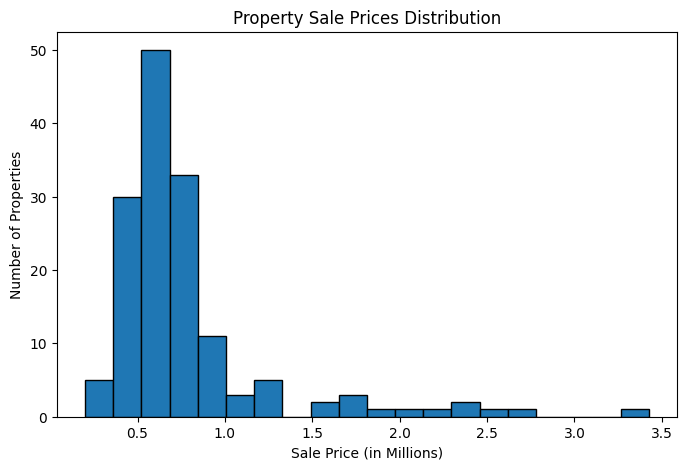

In [11]:
# Plotting the price distribution
plt.figure(figsize=(8, 5))

plt.hist(df["Sale_Price"].dropna()/ 1e6, bins=20, edgecolor="black")

plt.title("Property Sale Prices Distribution")
plt.xlabel("Sale Price (in Millions)")
plt.ylabel("Number of Properties")

plt.show()

In [12]:
# Sale prices by suburb
suburb_prices = ( df.groupby("Suburb")["Sale_Price"].agg(["count", "mean", "median", "min", "max"]).round(0))

suburb_prices

,count,mean,median,min,max
Suburb,,,,,
Canterbury,50,1109206.0,810500.0,510000,2700000
Liverpool,50,564040.0,520000.0,340000,1270000
Parramatta,50,672021.0,607500.0,200000,3425000


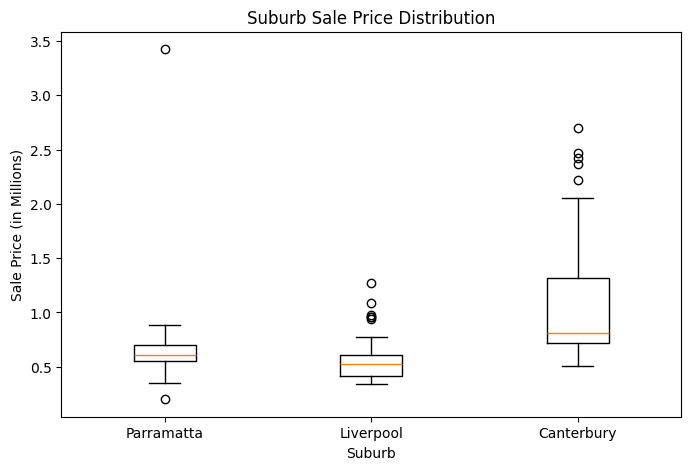

In [13]:
# Plotting the Suburb sale distribution

suburbs = df["Suburb"].dropna().unique()

price_by_suburb = [
    df.loc[df["Suburb"] == suburb, "Sale_Price"].dropna() / 1e6
    for suburb in suburbs
]

plt.figure(figsize=(8, 5))

plt.boxplot(price_by_suburb, tick_labels=suburbs)

plt.title("Suburb Sale Price Distribution")
plt.xlabel("Suburb")
plt.ylabel("Sale Price (in Millions)")

plt.show()

In [14]:
# Checking the different types of property
property_type = (df.groupby("Property_Type")["Sale_Price"].agg(["count", "mean", "median"]).sort_values("count", ascending=False).round(0))

property_type


,count,mean,median
Property_Type,,,
Apartment,95,654269.0,625000.0
Unit,30,527367.0,540500.0
House,18,1728600.0,1743500.0
Townhouse,4,924250.0,871000.0
Block of units,1,3425000.0,3425000.0
Studio,1,200000.0,200000.0
Villa,1,850000.0,850000.0


In [15]:
pd.crosstab(df["Suburb"], df["Property_Type"])

Property_Type,Apartment,Block of units,House,Studio,Townhouse,Unit,Villa
Suburb,,,,,,,
Canterbury,32,0,13,0,1,4,0
Liverpool,24,0,5,0,2,19,0
Parramatta,39,1,0,1,1,7,1


In [16]:
# Relationships with the property characteristics
# Bedrooms
bedroom_summary = (df.groupby("Bedrooms")["Sale_Price"].agg(["count", "median", "mean"]).round(0))

bedroom_summary

,count,median,mean
Bedrooms,,,
1,22,457500.0,469318.0
2,100,617500.0,672106.0
3,19,825000.0,1165105.0
4,6,1528500.0,1562833.0
5,2,2394400.0,2394400.0
12,1,3425000.0,3425000.0


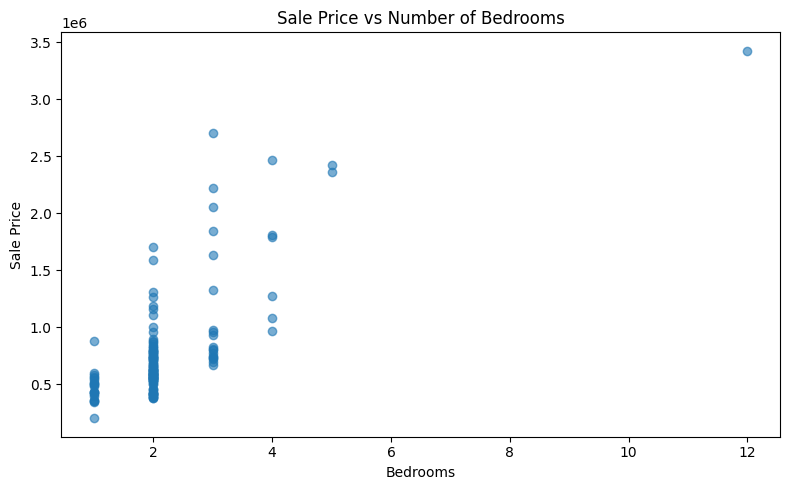

In [17]:
# Plotting the relationship between Bedroom and sale price
plt.figure(figsize=(8, 5))

plt.scatter(df["Bedrooms"], df["Sale_Price"], alpha=0.6)

plt.title("Sale Price vs Number of Bedrooms")
plt.xlabel("Bedrooms")
plt.ylabel("Sale Price")

plt.tight_layout()
plt.show()

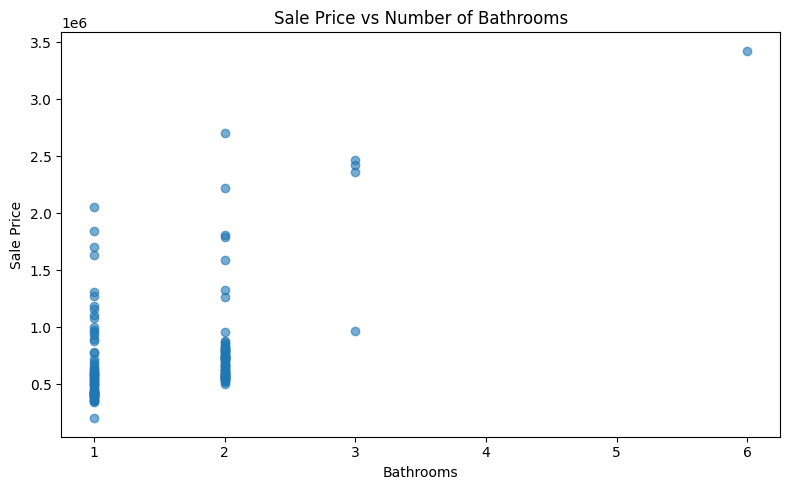

In [18]:
# Plotting the relationship between Bathrooms and sale price
plt.figure(figsize=(8, 5))

plt.scatter(df["Bathrooms"], df["Sale_Price"], alpha=0.6)

plt.title("Sale Price vs Number of Bathrooms")
plt.xlabel("Bathrooms")
plt.ylabel("Sale Price")

plt.tight_layout()
plt.show()

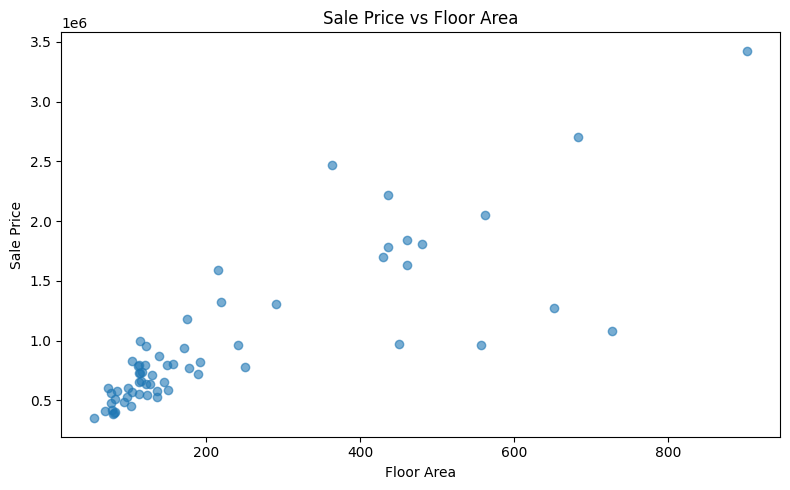

In [19]:
# Plotting the relationship between Floor Area and sale price
floor_data = df.dropna(subset=["Floor_Area_m2"])

plt.figure(figsize=(8, 5))

plt.scatter(floor_data["Floor_Area_m2"],floor_data["Sale_Price"], alpha=0.6)

plt.title("Sale Price vs Floor Area")
plt.xlabel("Floor Area")
plt.ylabel("Sale Price")

plt.tight_layout()
plt.show()

In [20]:
# Plotting the price trend over time
monthly_prices = (df.set_index("Sale_Date").resample("ME")["Sale_Price"].agg(["mean", "median", "count"]))

monthly_prices

,mean,median,count
Sale_Date,,,
2026-03-31,1.630000e+06,1630000.0,1
2026-04-30,1.109056e+06,795000.0,18
2026-05-31,1.238946e+06,826500.0,13
2026-06-30,8.824286e+05,620000.0,7
2026-07-31,6.823830e+05,600000.0,55
2026-08-31,6.160204e+05,560000.0,49
2026-09-30,8.101429e+05,705000.0,7


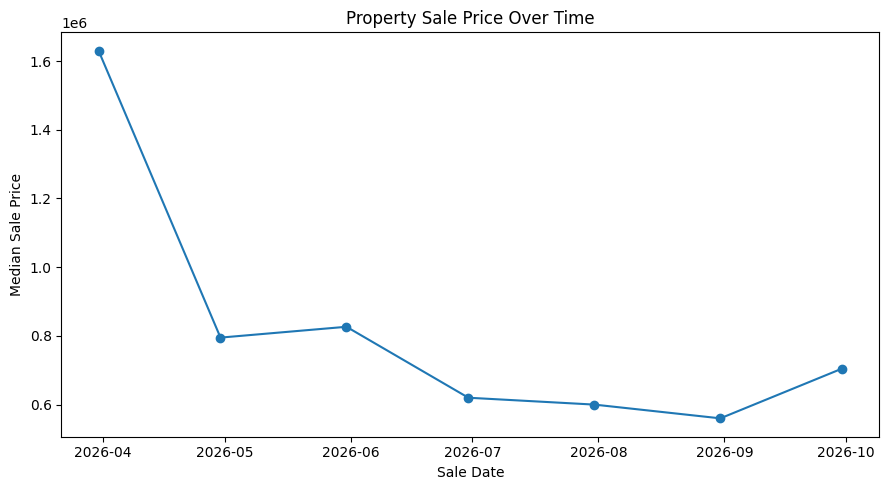

In [21]:
# Plotting the price trend over time
plt.figure(figsize=(9, 5))

plt.plot(monthly_prices.index,monthly_prices["median"],marker="o")

plt.title("Property Sale Price Over Time")
plt.xlabel("Sale Date")
plt.ylabel("Median Sale Price")

plt.tight_layout()
plt.show()

In [22]:
# Identifying the outliers
Q1 = df["Sale_Price"].quantile(0.25)
Q3 = df["Sale_Price"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df["Sale_Price"] < lower_bound) | (df["Sale_Price"] > upper_bound)].copy()

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)
print("Number of price outliers:", len(outliers))

outliers[["Address", "Suburb", "Sale_Price","Bedrooms", "Bathrooms", "Property_Type"]].sort_values("Sale_Price", ascending=False)

Q1: 532750.0
Q3: 800000.0
IQR: 267250.0
Lower bound: 131875.0
Upper bound: 1200875.0
Number of price outliers: 17


,Address,Suburb,Sale_Price,Bedrooms,Bathrooms,Property_Type
2,"37A Sutherland Road, Parramatta",Parramatta,3425000,12,6,Block of units
118,"4 Mons Street, Canterbury",Canterbury,2700000,3,2,House
114,"20 Allen Street, Canterbury",Canterbury,2470000,4,3,House
113,"5b Cooks Avenue, Canterbury",Canterbury,2425000,5,3,House
147,"13 Cooks Avenue, Canterbury",Canterbury,2363800,5,3,House
106,"43 Howard Street, Canterbury",Canterbury,2220000,3,2,House
130,"27 Howard Street, Canterbury",Canterbury,2050000,3,1,House
142,"17 Page Street, Canterbury",Canterbury,1845000,3,1,House
119,"20 Page Street, Canterbury",Canterbury,1805000,4,2,House
144,"4 Glenore Road, Canterbury",Canterbury,1787000,4,2,House


After looking at all the plots and before feature engineering and model training, the three variables expected to have the strongest influence on the sale price are:
1. Suburbs - the location of the properties are expected to capture differences in the market

2. Property type - like houses, apartments, townhouses and other property types differ in size and market characteristics.

3. Bedrooms - the number of bedrooms provides a consistent indicator for sales prices

Although the floor area is an important predictor theoretically, it is not among the top thress as the dataset has a good amount of properties without the floor area 

In [23]:
# Feature Engineering
# Creating a copy
model_data = df.copy()

# Mapping the different property types
property_type_map = {
    "Apartment": "Apartment_Unit",
    "Unit": "Apartment_Unit",
    "Studio": "Apartment_Unit",
    "House": "House",
    "Townhouse": "Other",
    "Villa": "Other",
    "Block of units": "Other"
}

model_data["Property_Type_Grouped"] = (
    model_data["Property_Type"]
    .map(property_type_map)
)

model_data["Property_Type_Grouped"].value_counts()

Property_Type_Grouped
Apartment_Unit    126
House              18
Other               6
Name: count, dtype: int64

In [24]:
# Extracting sales per month
model_data["Sale_Month"] = model_data["Sale_Date"].dt.month

print("Sale years:")
print(model_data["Sale_Date"].dt.year.value_counts())

print("\nSale months:")
print(model_data["Sale_Month"].value_counts().sort_index())

Sale years:
Sale_Date
2026    150
Name: count, dtype: int64

Sale months:
Sale_Month
3     1
4    18
5    13
6     7
7    55
8    49
9     7
Name: count, dtype: int64


In [25]:
# Preparing feature and target variable 
features = [
    "Suburb",
    "Bedrooms",
    "Bathrooms",
    "Parking",
    "Floor_Area_m2",
    "Property_Type_Grouped",
    "Sale_Month"
]

target = "Sale_Price"

X = model_data[features].copy()
target = model_data[target].copy()

print("Features:", X.shape)
print("Target:", target.shape)

X.head()

Features: (150, 7)
Target: (150,)


,Suburb,Bedrooms,Bathrooms,Parking,Floor_Area_m2,Property_Type_Grouped,Sale_Month
0,Parramatta,2,2,1.0,NaN,Apartment_Unit,7
1,Parramatta,2,2,1.0,115.0,Apartment_Unit,7
2,Parramatta,12,6,6.0,903.4,Other,7
3,Parramatta,2,2,1.0,103.0,Apartment_Unit,7
4,Parramatta,2,2,1.0,NaN,Apartment_Unit,7


Housing prices vary considerably across the three suburbs and different property types.

Canterbury has one of the highest median sale price, with $810,500, when compared with Parramatta ($607,500) and Liverpool ($520,000). Prices generally increases with the number of bedrooms and floor area.

 17 price outliers have been identified using the IQR method, and these observations were retained as they look to be representing high value properties rather than being errors. 

Property types have been grouped to reduce very sparse categories before modelling. 

---

## Part 3: Model Development and Evaluation

### Model selection

Here I have selected three regresssion approaches and then evalutating them to find the best model.
The three approaches are:

1. Ridge Regression, as it provides a regularised linear baseline. Its easily interpretable and computationally efficient, but may underfit if housing prices depend on nonlinear/complex relationships.

2. Random Forest Regression, as it combines mnay decision tress and can capture nonlinear relationships and interactions. But, it may overfit a relatively small dataset and is less interpretable than a linear model.

3. Gradient Boosting Regression, as it can sequentially combine weak decision trees to model a complex relationships. It can achieve a strong predictive performance but have to be careful about model complexity.

In [26]:
# Splitting the data set into train and test
# we will split it 80:20
X_train, X_test, target_train, target_test = train_test_split(
    X,
    target,
    test_size=0.20,
    random_state=RANDOM_STATE
)

print("Training Dataset:", len(X_train))
print("Testing Dataset", len(X_test))

Training Dataset: 120
Testing Dataset 30


In [27]:
# Seperating the numerical and categorical variables
numerical_features = [
    "Bedrooms",
    "Bathrooms",
    "Parking",
    "Floor_Area_m2",
    "Sale_Month"
]

categorical_features = [
    "Suburb",
    "Property_Type_Grouped"
]

# Preprocessing the features using pipeline
# Numerical preprocessing
numerical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Categorical preprocessing
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# Combining the two preprocessing
feature_preprocessor = ColumnTransformer(
    transformers=[
        ("num", numerical_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [28]:
# Defining the models
models = {
    "Ridge Regression": Ridge(alpha=1.0),

    "Random Forest": RandomForestRegressor(
        n_estimators=300,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingRegressor(random_state=RANDOM_STATE)
}

In [29]:
# Training and evaluating the models using k-fold cross-validation 
cv = KFold(n_splits=5,shuffle=True,random_state=RANDOM_STATE)

metrics = {
    "MAE": "neg_mean_absolute_error",
    "MSE": "neg_mean_squared_error",
    "R2": "r2"
}

results = []

for model_name, model in models.items():
    pipeline = Pipeline(steps = [
        ("preprocessor", feature_preprocessor),
        ("model", model)
    ])

    scores = cross_validate(
        pipeline,
        X_train,
        target_train,
        cv=cv,
        scoring=metrics,
        return_train_score=True,
        n_jobs=-1
    )

    results.append({
        "Model": model_name,

        "Train_MAE": -scores["train_MAE"].mean(),
        "CV_MAE": -scores["test_MAE"].mean(),

        "Train_RMSE": np.sqrt(-scores["train_MSE"].mean()),
        "CV_RMSE": np.sqrt(-scores["test_MSE"].mean()),

        "Train_R2": scores["train_R2"].mean(),
        "CV_R2": scores["test_R2"].mean(),

        "CV_MAE_SD": (-scores["test_MAE"]).std()
    })

results_df = pd.DataFrame(results)
results_df.round(3)

,Model,Train_MAE,CV_MAE,Train_RMSE,CV_RMSE,Train_R2,CV_R2,CV_MAE_SD
0,Ridge Regression,106071.418,115528.029,142910.581,159550.603,0.916,0.857,29836.389
1,Random Forest,61236.118,133590.017,112143.646,271334.788,0.949,0.761,57076.637
2,Gradient Boosting,43215.375,129299.306,66888.790,264254.837,0.982,0.746,41655.209


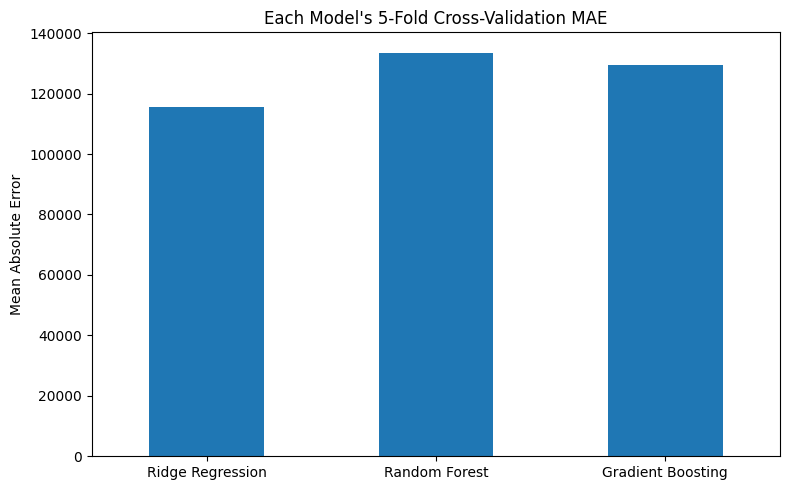

In [30]:
# Plotting each model's 5-Fold Cross-Validation MAE 
plot_data = results_df.set_index("Model")

plt.figure(figsize=(8, 5))

plot_data["CV_MAE"].plot(kind="bar")

plt.title("Each Model's 5-Fold Cross-Validation MAE")
plt.ylabel("Mean Absolute Error")
plt.xlabel("")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

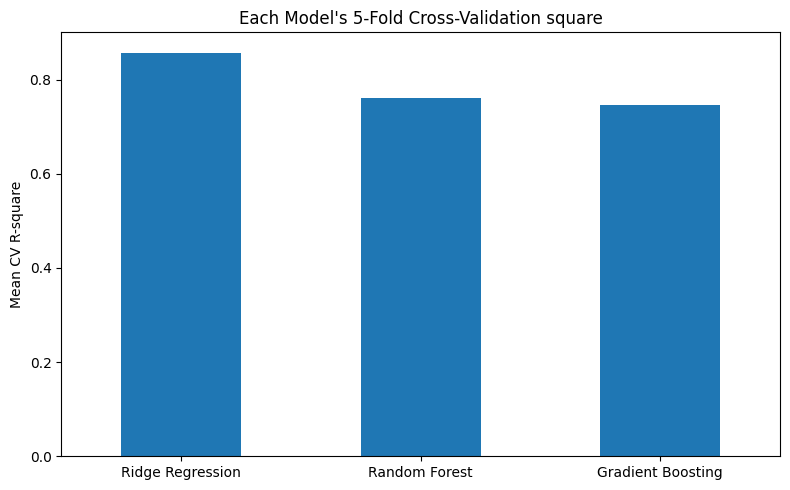

In [31]:
# Plotting each model's 5-Fold Cross-Validation R square 

plt.figure(figsize=(8, 5))

plot_data["CV_R2"].plot(kind="bar")

plt.title("Each Model's 5-Fold Cross-Validation square")
plt.ylabel("Mean CV R-square")
plt.xlabel("")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [32]:
# Examing if the model is underfitting or overfitting 
results_df["MAE_Gap"] = (results_df["CV_MAE"] -results_df["Train_MAE"])

results_df["R2_Gap"] = (results_df["Train_R2"] - results_df["CV_R2"])

results_df[
    [
        "Model",
        "Train_MAE",
        "CV_MAE",
        "MAE_Gap",
        "Train_R2",
        "CV_R2",
        "R2_Gap"
    ]
].round(3)

,Model,Train_MAE,CV_MAE,MAE_Gap,Train_R2,CV_R2,R2_Gap
0,Ridge Regression,106071.418,115528.029,9456.611,0.916,0.857,0.058
1,Random Forest,61236.118,133590.017,72353.899,0.949,0.761,0.188
2,Gradient Boosting,43215.375,129299.306,86083.931,0.982,0.746,0.236


### Hyperparameter Tuning

From the baseline cross-validation results, we can see that the Randon Forest and the Gradient Boosting has achieved a substantially better training performance than validation performance, which suggests overfitting. Therefore, hyperparameters controlling teh model complexity has to be tuned.

Ridge regularisation strength was also evaluated to provide a fiar comparison across all the three models. Although Five-fold cross-validation was retained, MAE was the primary criteria.

In [33]:
from sklearn.model_selection import GridSearchCV

# Tuning Ridge parameters
ridge_parameters = {
    "model__alpha": [0.01, 0.1, 1, 10]
}

ridge_pipeline = Pipeline(steps=[
    ("preprocessor", feature_preprocessor),
    ("model", Ridge())
])

ridge_grid = GridSearchCV(
    estimator=ridge_pipeline,
    param_grid=ridge_parameters,
    cv=cv,
    scoring="neg_mean_absolute_error",
    n_jobs=-1
)

ridge_grid.fit(X_train, target_train)

print("Best Ridge parameters:", ridge_grid.best_params_)
print(f"Best Ridge CV MAE: ${-ridge_grid.best_score_:,.2f}")

Best Ridge parameters: {'model__alpha': 1}
Best Ridge CV MAE: $115,528.03


In [34]:
# Random Forest Tuning
rf_parameters = {
    "model__n_estimators": [200, 300],
    "model__max_depth": [3, 5, None],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2, 4]
}

rf_pipeline = Pipeline(steps=[
    ("preprocessor", feature_preprocessor),
    ("model", RandomForestRegressor(
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

rf_grid = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=rf_parameters,
    cv=cv,
    scoring="neg_mean_absolute_error",
    n_jobs=-1
)

rf_grid.fit(X_train, target_train)

print("Best Random Forest parameters:")
print(rf_grid.best_params_)

print(f"Best Random Forest CV MAE: ${-rf_grid.best_score_:,.2f}")

Best Random Forest parameters:
{'model__max_depth': 5, 'model__min_samples_leaf': 2, 'model__min_samples_split': 2, 'model__n_estimators': 300}
Best Random Forest CV MAE: $129,257.97


In [35]:
# Gradient Boosting tuning
gb_parameters = {
    "model__n_estimators": [50, 100, 200],
    "model__learning_rate": [0.01, 0.05, 0.1],
    "model__max_depth": [1, 2, 3],
    "model__min_samples_leaf": [1, 3, 5]
}

gb_pipeline = Pipeline(steps=[
    ("preprocessor", feature_preprocessor),
    ("model", GradientBoostingRegressor(
        random_state=RANDOM_STATE
    ))
])

gb_grid = GridSearchCV(
    estimator=gb_pipeline,
    param_grid=gb_parameters,
    cv=cv,
    scoring="neg_mean_absolute_error",
    n_jobs=-1
)

gb_grid.fit(X_train, target_train)

print("Best Gradient Boosting parameters:")
print(gb_grid.best_params_)

print(f"Best Gradient Boosting CV MAE: ${-gb_grid.best_score_:,.2f}")

Best Gradient Boosting parameters:
{'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__min_samples_leaf': 3, 'model__n_estimators': 100}
Best Gradient Boosting CV MAE: $118,348.86


In [36]:
# Comparing the baseline and the tuned models
tuned_models_comparison = pd.DataFrame({
    "Model":["Ridge Regression","Random Forest", "Gradient Boosting"],
    "Baseline_CV_MAE": [results_df.loc[results_df["Model"] == "Ridge Regression","CV_MAE"].iloc[0],
                       results_df.loc[results_df["Model"] == "Random Forest","CV_MAE"].iloc[0],
                       results_df.loc[results_df["Model"] == "Gradient Boosting","CV_MAE"].iloc[0],],
    "Tuned_CV_MAE": [-ridge_grid.best_score_, -rf_grid.best_score_,-gb_grid.best_score_],
})

results_df.loc[results_df["Model"] == "Ridge Regression","CV_MAE"].iloc[0],
tuned_models_comparison["Improvement"] = (tuned_models_comparison["Baseline_CV_MAE"]-tuned_models_comparison["Tuned_CV_MAE"])

tuned_models_comparison.round(2)

,Model,Baseline_CV_MAE,Tuned_CV_MAE,Improvement
0,Ridge Regression,115528.03,115528.03,0.00
1,Random Forest,133590.02,129257.97,4332.05
2,Gradient Boosting,129299.31,118348.86,10950.45


In [37]:
# Selecting the best model 

tuned_models = {
    "Ridge Regression": ridge_grid.best_estimator_,
    "Random Forest": rf_grid.best_estimator_,
    "Gradient Boosting": gb_grid.best_estimator_
}

best_tuned_model = (tuned_models_comparison.sort_values("Tuned_CV_MAE").iloc[0]["Model"])

best_pipeline = tuned_models[best_tuned_model]

print("The best model, based on the lowest CV MAE:", best_tuned_model)

The best model, based on the lowest CV MAE: Ridge Regression


In [38]:
# Testing the model

predictions_test = best_pipeline.predict(X_test)

test_mae = mean_absolute_error( target_test, predictions_test)
test_rmse = np.sqrt(mean_squared_error(target_test, predictions_test))
test_rsquared = r2_score(target_test, predictions_test)


print(f"Test MAE: {test_mae:,.2f}")
print(f"Test RMSE: {test_rmse:,.2f}")
print(f"Test R-squared: {test_rsquared:.3f}")

Test MAE: 123,116.85
Test RMSE: 211,402.31
Test R-squared: 0.803


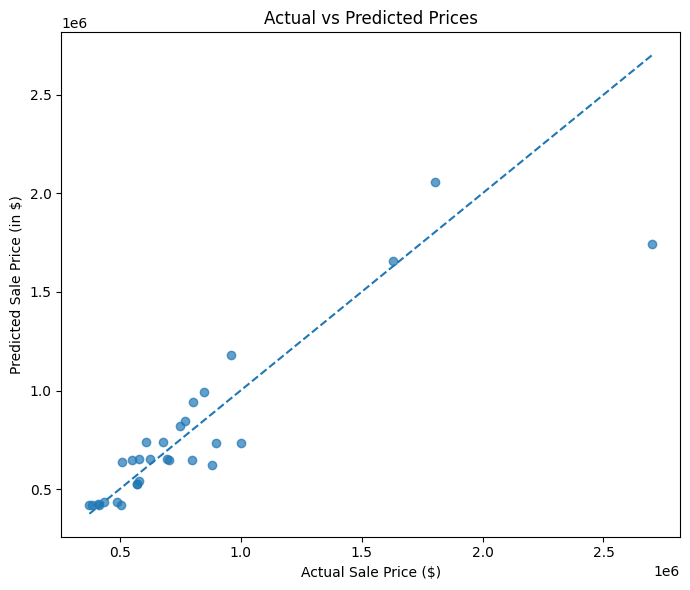

In [39]:
# Actual vs Predicted 
plt.figure(figsize=(7, 6))

plt.scatter(
    target_test,predictions_test,alpha=0.7)

minimum = min(target_test.min(), predictions_test.min())
maximum = max(target_test.max(), predictions_test.max())

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    linestyle="--"
)

plt.xlabel("Actual Sale Price ($)")
plt.ylabel("Predicted Sale Price (in $)")
plt.title("Actual vs Predicted Prices")

plt.tight_layout()
plt.show()

In [40]:
# Copying the test prediction results for later
test_results = X_test.copy()

test_results["Actual_Price"] = target_test
test_results["Predicted_Price"] = predictions_test

test_results["Absolute_Error"] = np.abs(test_results["Actual_Price"] - test_results["Predicted_Price"])

test_results = test_results.sort_values("Absolute_Error",ascending=False)

test_results.head(10)

,Suburb,Bedrooms,Bathrooms,Parking,Floor_Area_m2,Property_Type_Grouped,Sale_Month,Actual_Price,Predicted_Price,Absolute_Error
118,Canterbury,3,2,2.0,682.9,House,4,2700000,1.741696e+06,958303.680353
109,Canterbury,2,1,1.0,114.0,Apartment_Unit,8,1000000,7.351058e+05,264894.232593
108,Canterbury,1,1,1.0,NaN,Apartment_Unit,9,880000,6.231727e+05,256827.267007
119,Canterbury,4,2,3.0,481.0,House,4,1805000,2.054972e+06,249971.909898
76,Liverpool,4,3,1.0,241.0,Other,8,962000,1.180864e+06,218863.525333
100,Canterbury,2,1,1.0,NaN,Apartment_Unit,7,900000,7.352090e+05,164790.968292
35,Parramatta,2,2,1.0,NaN,Apartment_Unit,8,800000,6.498722e+05,150127.761772
6,Parramatta,2,2,1.0,NaN,Other,7,850000,9.919393e+05,141939.299836
19,Parramatta,3,2,2.0,157.0,Apartment_Unit,7,805000,9.404486e+05,135448.577307
126,Canterbury,2,1,1.0,NaN,Apartment_Unit,4,610000,7.399342e+05,129934.249461


Ridge Regression achieved the strongest cross-validation performance, and had the lowest CV MAE ($115,528), and had the highest CV R-square (0.857). 

Its relatively small train–validation gaps indicate it has better generalisation than Random Forest and Gradient Boosting, which show an evidence of overfitting.

The hyperparameter tuning improved Random Forest by $4,332 and Gradient Boosting by $10,950, while Ridge remained unchanged. Although the tuning has substantially improved Gradient Boosting, its
CV MAE ($118,349) remained slightly higher than Ridge ($115,528).
Therefore, Ridge Regression was selected as the final model.

This shows us that the the simpler regularised model generalised better for this relatively small dataset.

On the test set, Ridge achieved MAE of $123,117, RMSE of $211,402 and R-squared of 0.803. This incdicates strong generalisation although the difference between MAE and RMSE may suggest that some properties might have produced substantially larger prediction errors.

Therefore, the excepectation that Gradient Boosting would perform best, wasnt supported by the results.

---

## Part 4: Investigating Prediction Failures

There are five properties with the largest absolute prediction errors from the test set, and these are examined to understand the situations in which the final model performs poorly

Absolute error is calculated as the difference between the actual and predicted sale price. 

These are investigated instead of removing them, ad larger prediction errors may actually be genuine properties that are difficult for the model to value.

In [41]:
# Creating detailed results for the test properties
error_analysis = X_test.copy()

# Since X_test.copy() didn't have address and property type
# We will add it
error_analysis["Address"] = df.loc[X_test.index, "Address"]
error_analysis["Original_Property_Type"] = df.loc[X_test.index, "Property_Type"]

error_analysis["Actual_Price"] = target_test
error_analysis["Predicted_Price"] = predictions_test

error_analysis["Error"] = (error_analysis["Predicted_Price"] -error_analysis["Actual_Price"])

error_analysis["Absolute_Error"] = np.abs(error_analysis["Error"])

error_analysis["Percentage_Error"] = (error_analysis["Absolute_Error"] /error_analysis["Actual_Price"] * 100)

error_analysis = error_analysis.sort_values("Absolute_Error",ascending=False)

error_analysis.head()

,Suburb,Bedrooms,Bathrooms,Parking,Floor_Area_m2,Property_Type_Grouped,Sale_Month,Address,Original_Property_Type,Actual_Price,Predicted_Price,Error,Absolute_Error,Percentage_Error
118,Canterbury,3,2,2.0,682.9,House,4,"4 Mons Street, Canterbury",House,2700000,1.741696e+06,-958303.680353,958303.680353,35.492729
109,Canterbury,2,1,1.0,114.0,Apartment_Unit,8,"10/22-26 Phillips Avenue, Canterbury",Apartment,1000000,7.351058e+05,-264894.232593,264894.232593,26.489423
108,Canterbury,1,1,1.0,NaN,Apartment_Unit,9,"55/20 Close Street, Canterbury",Apartment,880000,6.231727e+05,-256827.267007,256827.267007,29.184917
119,Canterbury,4,2,3.0,481.0,House,4,"20 Page Street, Canterbury",House,1805000,2.054972e+06,249971.909898,249971.909898,13.848859
76,Liverpool,4,3,1.0,241.0,Other,8,"1/10 Tobruk Avenue, Liverpool",Townhouse,962000,1.180864e+06,218863.525333,218863.525333,22.750886


In [42]:
five_worst_errors = error_analysis.head(5).copy()

five_worst_errors[
    [
        "Address",
        "Suburb",
        "Original_Property_Type",
        "Bedrooms",
        "Bathrooms",
        "Parking",
        "Floor_Area_m2",
        "Actual_Price",
        "Predicted_Price",
        "Error",
        "Absolute_Error",
        "Percentage_Error"
    ]
].round(2)

,Address,Suburb,Original_Property_Type,Bedrooms,Bathrooms,Parking,Floor_Area_m2,Actual_Price,Predicted_Price,Error,Absolute_Error,Percentage_Error
118,"4 Mons Street, Canterbury",Canterbury,House,3,2,2.0,682.9,2700000,1741696.32,-958303.68,958303.68,35.49
109,"10/22-26 Phillips Avenue, Canterbury",Canterbury,Apartment,2,1,1.0,114.0,1000000,735105.77,-264894.23,264894.23,26.49
108,"55/20 Close Street, Canterbury",Canterbury,Apartment,1,1,1.0,NaN,880000,623172.73,-256827.27,256827.27,29.18
119,"20 Page Street, Canterbury",Canterbury,House,4,2,3.0,481.0,1805000,2054971.91,249971.91,249971.91,13.85
76,"1/10 Tobruk Avenue, Liverpool",Liverpool,Townhouse,4,3,1.0,241.0,962000,1180863.53,218863.53,218863.53,22.75


In [43]:
# Checking if the model is overpredicting or underpredicting
five_worst_errors["Error_Type"] = np.where(five_worst_errors["Error"] > 0, "Overpredicted","Underpredicted")

five_worst_errors[
    [
        "Address",
        "Actual_Price",
        "Predicted_Price",
        "Absolute_Error",
        "Error_Type"
    ]
]



,Address,Actual_Price,Predicted_Price,Absolute_Error,Error_Type
118,"4 Mons Street, Canterbury",2700000,1.741696e+06,958303.680353,Underpredicted
109,"10/22-26 Phillips Avenue, Canterbury",1000000,7.351058e+05,264894.232593,Underpredicted
108,"55/20 Close Street, Canterbury",880000,6.231727e+05,256827.267007,Underpredicted
119,"20 Page Street, Canterbury",1805000,2.054972e+06,249971.909898,Overpredicted
76,"1/10 Tobruk Avenue, Liverpool",962000,1.180864e+06,218863.525333,Overpredicted


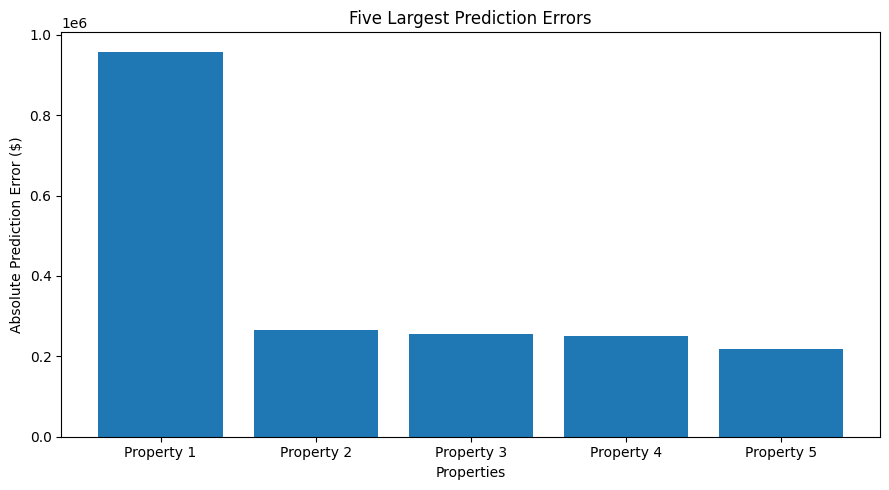

In [44]:
# Plotting the prediction errors
plt.figure(figsize=(9, 5))

plt.bar(range(1, 6),five_worst_errors["Absolute_Error"])

plt.xticks(range(1, 6),[f"Property {i}" for i in range(1, 6)])

plt.ylabel("Absolute Prediction Error ($)")
plt.xlabel("Properties")
plt.title("Five Largest Prediction Errors")

plt.tight_layout()
plt.show()

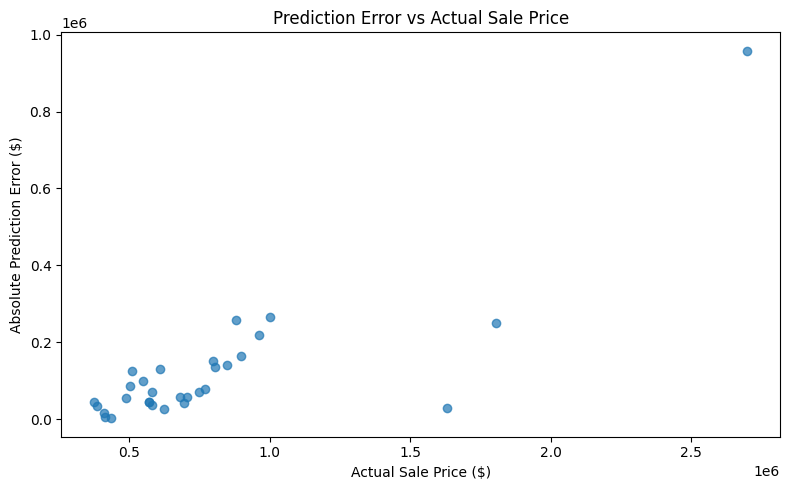

Correlation between actual price and absolute error: 0.832


In [45]:
# Checking if the expensive properties are harder to predict
plt.figure(figsize=(8, 5))

plt.scatter(
    error_analysis["Actual_Price"],
    error_analysis["Absolute_Error"],
    alpha=0.7
)

plt.xlabel("Actual Sale Price ($)")
plt.ylabel("Absolute Prediction Error ($)")
plt.title("Prediction Error vs Actual Sale Price")

plt.tight_layout()
plt.show()

price_error_correlation = error_analysis[ ["Actual_Price", "Absolute_Error"]].corr().iloc[0, 1]

print("Correlation between actual price and absolute error:",round(price_error_correlation, 3))

In [46]:
# Calculating the error by suburb

suburb_error = (error_analysis.groupby("Suburb")
                .agg(
                    Properties=("Absolute_Error","size"),
                    MAE =("Absolute_Error","mean"),
                    Median_Error=("Absolute_Error","median")
                ).round(2))

suburb_error

,Properties,MAE,Median_Error
Suburb,,,
Canterbury,10,231402.94,147362.61
Liverpool,9,62380.52,43502.05
Parramatta,11,74368.31,56702.83


In [47]:
# Calculating the error by property type

property_type_error = (error_analysis.groupby("Property_Type_Grouped")
                .agg(
                    Properties=("Absolute_Error","size"),
                    MAE =("Absolute_Error","mean"),
                    Median_Error=("Absolute_Error","median")
                ).round(2))

property_type_error

,Properties,MAE,Median_Error
Property_Type_Grouped,,,
Apartment_Unit,25,83832.34,56784.10
House,3,412298.09,249971.91
Other,2,180401.41,180401.41


The largest prediction error occured in 4 Mons Street, Canterbury. The model underpredicted the sale price by about $958,304. This is one of the properties where the sale price was an outlier. Overall, the prediction error had a strong positive relationship with the sale price which tells us that the properties with higher prices were more difficult to predict

Suburb wise, Canterbury had the highest MAE with $231,403, while the houses had the highest MAE with $412,298 in property types.

However, the property_type results should be interpreted with caution as the test set had only three houses.

---

## Part 5: Human Judgement, Machine Learning, and Large Language Models

In [48]:
# Selecting 10 rando properties from the held out test set
comparison_sample = error_analysis.sample(
    n=10,
    random_state=RANDOM_STATE
).copy()

comparison_sample[
    [
        "Address",
        "Suburb",
        "Original_Property_Type",
        "Bedrooms",
        "Bathrooms",
        "Parking",
        "Floor_Area_m2"
    ]
]

,Address,Suburb,Original_Property_Type,Bedrooms,Bathrooms,Parking,Floor_Area_m2
19,"1/6 Sorrell St, Parramatta",Parramatta,Apartment,3,2,2.0,157.0
40,"1702/45 Macquarie Street, Parramatta",Parramatta,Apartment,2,2,1.0,NaN
76,"1/10 Tobruk Avenue, Liverpool",Liverpool,Townhouse,4,3,1.0,241.0
118,"4 Mons Street, Canterbury",Canterbury,House,3,2,2.0,682.9
68,"15/13 Speed Street, Liverpool",Liverpool,Unit,2,1,1.0,NaN
99,"503/311 Hume Highway, Liverpool",Liverpool,Apartment,2,2,1.0,NaN
43,"9/178 George Street, Parramatta",Parramatta,Apartment,1,1,NaN,93.0
24,"34/105-107 Church Street, Parramatta",Parramatta,Apartment,2,2,1.0,NaN
37,"401/8 River Road, Parramatta",Parramatta,Apartment,2,2,1.0,NaN
16,"35/26-30 Hassall Street, Parramatta",Parramatta,Apartment,2,2,1.0,NaN


In [49]:
# The LLM inputs
llm_input = comparison_sample[
    [
        "Address",
        "Suburb",
        "Original_Property_Type",
        "Bedrooms",
        "Bathrooms",
        "Parking",
        "Floor_Area_m2",
        "Sale_Month"
    ]
].copy()

llm_input

,Address,Suburb,Original_Property_Type,Bedrooms,Bathrooms,Parking,Floor_Area_m2,Sale_Month
19,"1/6 Sorrell St, Parramatta",Parramatta,Apartment,3,2,2.0,157.0,7
40,"1702/45 Macquarie Street, Parramatta",Parramatta,Apartment,2,2,1.0,NaN,9
76,"1/10 Tobruk Avenue, Liverpool",Liverpool,Townhouse,4,3,1.0,241.0,8
118,"4 Mons Street, Canterbury",Canterbury,House,3,2,2.0,682.9,4
68,"15/13 Speed Street, Liverpool",Liverpool,Unit,2,1,1.0,NaN,7
99,"503/311 Hume Highway, Liverpool",Liverpool,Apartment,2,2,1.0,NaN,8
43,"9/178 George Street, Parramatta",Parramatta,Apartment,1,1,NaN,93.0,9
24,"34/105-107 Church Street, Parramatta",Parramatta,Apartment,2,2,1.0,NaN,7
37,"401/8 River Road, Parramatta",Parramatta,Apartment,2,2,1.0,NaN,8
16,"35/26-30 Hassall Street, Parramatta",Parramatta,Apartment,2,2,1.0,NaN,7


In [50]:
# my own estimates
my_estimates = [
    1800000,
    800000,
    1030000,
    2800000,
    450000,
    860000,
    500000,
    800000,
    820000,
    800000
]

# LLMs estiamtes
llm_estimates = [
    1050000,
    820000,
    1050000,
    2250000,
    600000,
    650000,
    570000,
    760000,
    780000,
    750000
]

comparison_sample["My_Prediction"] = my_estimates
comparison_sample["LLM_Prediction"] = llm_estimates

In [51]:
# Combining the Model's, LLM's and My prediction into a single result
comparison_results = comparison_sample[
    [
        "Address",
        "Suburb",
        "Actual_Price",
        "Predicted_Price",
        "LLM_Prediction",
        "My_Prediction"
    ]
].copy()

comparison_results = comparison_results.rename(columns={"Predicted_Price": "Model_Prediction"})

comparison_results.round(2)

,Address,Suburb,Actual_Price,Model_Prediction,LLM_Prediction,My_Prediction
19,"1/6 Sorrell St, Parramatta",Parramatta,805000,940448.58,1050000,1800000
40,"1702/45 Macquarie Street, Parramatta",Parramatta,705000,648297.17,820000,800000
76,"1/10 Tobruk Avenue, Liverpool",Liverpool,962000,1180863.53,1050000,1030000
118,"4 Mons Street, Canterbury",Canterbury,2700000,1741696.32,2250000,2800000
68,"15/13 Speed Street, Liverpool",Liverpool,415000,420092.15,600000,450000
99,"503/311 Hume Highway, Liverpool",Liverpool,570000,526497.95,650000,860000
43,"9/178 George Street, Parramatta",Parramatta,490000,435109.66,570000,500000
24,"34/105-107 Church Street, Parramatta",Parramatta,625000,651447.31,760000,800000
37,"401/8 River Road, Parramatta",Parramatta,550000,649872.24,780000,820000
16,"35/26-30 Hassall Street, Parramatta",Parramatta,580000,651447.31,750000,800000


In [52]:
# Calculating the error for each prediction
# for the model
comparison_results["Model_Error"] = np.abs(comparison_results["Actual_Price"] -comparison_results["Model_Prediction"])
comparison_results["Model_Error_percentage"] = (comparison_results["Model_Error"] / comparison_results["Actual_Price"]) * 100

# for the LLM
comparison_results["LLM_Error"] = np.abs(comparison_results["Actual_Price"] -comparison_results["LLM_Prediction"])
comparison_results["LLM_Error_percentage"] = (comparison_results["LLM_Error"] / comparison_results["Actual_Price"]) * 100
# for the My prediction
comparison_results["Human_Error"] = np.abs(comparison_results["Actual_Price"] -comparison_results["My_Prediction"])
comparison_results["Human_Error_percentage"] = (comparison_results["Human_Error"] / comparison_results["Actual_Price"]) * 100

comparison_results.round(2)

,Address,Suburb,Actual_Price,Model_Prediction,LLM_Prediction,My_Prediction,Model_Error,Model_Error_percentage,LLM_Error,LLM_Error_percentage,Human_Error,Human_Error_percentage
19,"1/6 Sorrell St, Parramatta",Parramatta,805000,940448.58,1050000,1800000,135448.58,16.83,245000,30.43,995000,123.60
40,"1702/45 Macquarie Street, Parramatta",Parramatta,705000,648297.17,820000,800000,56702.83,8.04,115000,16.31,95000,13.48
76,"1/10 Tobruk Avenue, Liverpool",Liverpool,962000,1180863.53,1050000,1030000,218863.53,22.75,88000,9.15,68000,7.07
118,"4 Mons Street, Canterbury",Canterbury,2700000,1741696.32,2250000,2800000,958303.68,35.49,450000,16.67,100000,3.70
68,"15/13 Speed Street, Liverpool",Liverpool,415000,420092.15,600000,450000,5092.15,1.23,185000,44.58,35000,8.43
99,"503/311 Hume Highway, Liverpool",Liverpool,570000,526497.95,650000,860000,43502.05,7.63,80000,14.04,290000,50.88
43,"9/178 George Street, Parramatta",Parramatta,490000,435109.66,570000,500000,54890.34,11.20,80000,16.33,10000,2.04
24,"34/105-107 Church Street, Parramatta",Parramatta,625000,651447.31,760000,800000,26447.31,4.23,135000,21.60,175000,28.00
37,"401/8 River Road, Parramatta",Parramatta,550000,649872.24,780000,820000,99872.24,18.16,230000,41.82,270000,49.09
16,"35/26-30 Hassall Street, Parramatta",Parramatta,580000,651447.31,750000,800000,71447.31,12.32,170000,29.31,220000,37.93


In [53]:
# Comparing the different approaches
comparison_of_approaches = pd.DataFrame({
    "Approach": ["Machine Learning","LLM","Human"],

    "MAE": [
        comparison_results["Model_Error"].mean(),
        comparison_results["LLM_Error"].mean(),
        comparison_results["Human_Error"].mean()
    ]})

comparison_of_approaches = comparison_of_approaches.sort_values("MAE")

comparison_of_approaches.round(2)

,Approach,MAE
0,Machine Learning,167057.0
1,LLM,177800.0
2,Human,225800.0


In [54]:
# Finding the best approach for each test observation
error_columns = [
    "Model_Error",
    "LLM_Error",
    "Human_Error"
]

# We will compare the error rows and find the least error
comparison_results["Best_Approach"] = (
    comparison_results[error_columns]
    .idxmin(axis=1)
    .str.replace("_Error", "")
)

comparison_results[
    [
        "Address",
        "Actual_Price",
        "Model_Error",
        "LLM_Error",
        "Human_Error",
        "Best_Approach"
    ]
]

,Address,Actual_Price,Model_Error,LLM_Error,Human_Error,Best_Approach
19,"1/6 Sorrell St, Parramatta",805000,135448.577307,245000,995000,Model
40,"1702/45 Macquarie Street, Parramatta",705000,56702.834356,115000,95000,Model
76,"1/10 Tobruk Avenue, Liverpool",962000,218863.525333,88000,68000,Human
118,"4 Mons Street, Canterbury",2700000,958303.680353,450000,100000,Human
68,"15/13 Speed Street, Liverpool",415000,5092.151157,185000,35000,Model
99,"503/311 Hume Highway, Liverpool",570000,43502.048391,80000,290000,Model
43,"9/178 George Street, Parramatta",490000,54890.340231,80000,10000,Human
24,"34/105-107 Church Street, Parramatta",625000,26447.310812,135000,175000,Model
37,"401/8 River Road, Parramatta",550000,99872.238228,230000,270000,Model
16,"35/26-30 Hassall Street, Parramatta",580000,71447.310812,170000,220000,Model


In [55]:
comparison_results["Best_Approach"].value_counts()

Best_Approach
Model    7
Human    3
Name: count, dtype: int64

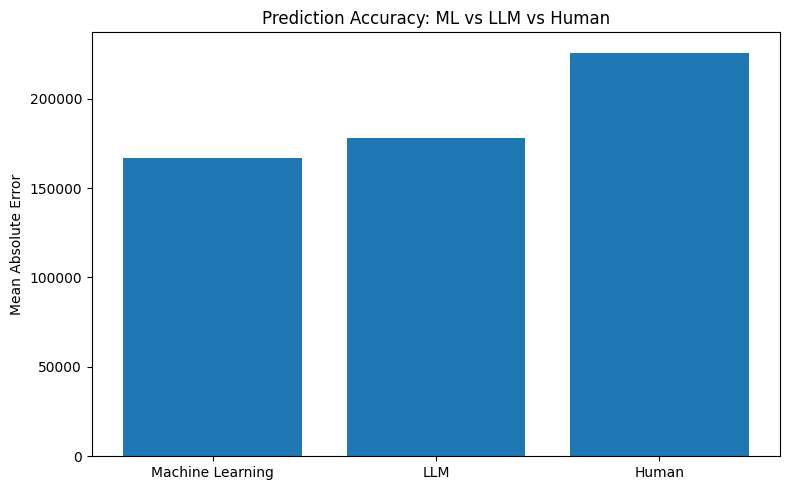

In [56]:
# Plotting the comparison graph
plt.figure(figsize=(8, 5))

plt.bar(
    comparison_of_approaches["Approach"],
    comparison_of_approaches["MAE"]
)

plt.ylabel("Mean Absolute Error")
plt.title("Prediction Accuracy: ML vs LLM vs Human")

plt.tight_layout()
plt.show()

Across the 10 selected test properties, the ML model has achieved the lowest overall MAE with $167,057, and followed by the LLM with MAE $177,800, while the human estimate had the highest MAE $225,800. 

Over ML model produced the closest estimate for 7 out of the 10 properties, while the human judgement was the best for 3.

Although the LLM prediction wasnt the best predictor for any of the properties, its overall MAE remained relatively close to ML. This tell us that each approach has their own strenghts, and we cant jump to conclusions based on a small 10-property comparison.

---

## Part 6: Final Deployment and Reflection

Here we will export the final Ridge Regression pipeline, so that we can deploy it in the Streamlit web application. Saving the entire pipeline, is necessary as it can ensure the same preprocessing steps and trained regression model are applied to new user inputs.

In [57]:
# Saving the trained pipeline
import joblib


joblib.dump(best_pipeline, "ridge_housing_model.pkl")
print("Final model saved successfully.")

Final model saved successfully.


In [58]:
# Verifying the deployment by reloading it
loaded_model = joblib.load("ridge_housing_model.pkl")

print(type(loaded_model))

<class 'sklearn.pipeline.Pipeline'>


In [59]:
# Sanity Test: Testing the saved model with a sample property
sample_property = pd.DataFrame({
    "Suburb": ["Parramatta"],
    "Bedrooms": [2],
    "Bathrooms": [2],
    "Parking": [1.0],
    "Floor_Area_m2": [100.0],
    "Property_Type_Grouped": ["Apartment_Unit"],
    "Sale_Month": [8]
})

sample_prediction = loaded_model.predict(sample_property)[0]
print(f"Sample predicted price: ${sample_prediction:,.2f}")

Sample predicted price: $652,815.85


In this project we developed an end-to-end ML model pipeline for predicting the housing market across the three suburbs Liverpool, Canterbury and Parramatta. After comparing and tuning the three regression models, we found Ridge Regression  to generalise the best. The final pipeline was then evaluated on the unseen properties and deployed through a Streamlit application.

## References:
1. scikit-learn developers (n.d.) sklearn.linear_model.Ridge. Available at: https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Ridge.html

2. scikit-learn developers (n.d.) sklearn.ensemble.RandomForestRegressor. Available at: https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestRegressor.html

3. scikit-learn developers (n.d.) sklearn.ensemble.GradientBoostingRegressor. Available at: https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.GradientBoostingRegressor.html

4. scikit-learn developers (n.d.) sklearn.pipeline.Pipeline. Available at: https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html#sklearn.pipeline.Pipeline

5. scikit-learn developers (n.d.) sklearn.compose.ColumnTransformer. Available at: https://scikit-learn.org/stable/modules/generated/sklearn.compose.ColumnTransformer.html

6. scikit-learn developers (n.d.) sklearn.impute.SimpleImputer. Available at: https://scikit-learn.org/stable/modules/generated/sklearn.impute.SimpleImputer.html

7. scikit-learn developers (n.d.) sklearn.preprocessing.OneHotEncoder. Available at: https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html

8. scikit-learn developers (n.d.) Cross-validation: evaluating estimator performance. Available at: https://scikit-learn.org/stable/modules/cross_validation.html

9. scikit-learn developers (n.d.) sklearn.model_selection.KFold. Available at: https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.KFold.html

10. scikit-learn developers (n.d.) sklearn.model_selection.GridSearchCV. Available at: https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html

11. scikit-learn developers (n.d.) sklearn.metrics.mean_absolute_error. Available at: https://scikit-learn.org/stable/modules/generated/sklearn.metrics.mean_absolute_error.html

12. Streamlit (n.d.) Create an app. Available at: https://docs.streamlit.io/get-started/tutorials/create-an-app

13. Used AI to understand the requirements, parse the images to get the speed up the dataset creating process, debug code errors, and correct the grammar.